<a href="https://colab.research.google.com/github/Juan-Vega18/INTRODUC.-CIENCIA-DE-DATOS/blob/main/PARCIAL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.random.mtrand import random

In [6]:
#Generación de un Dataset multivariable complejo (1000 empleados)
np.random.seed(10) #Semilla 42 porque queremos que el generador pseudo-aleatorio se comporte de la manera adecuada.
n_empleados = 1000

df_hr = pd.DataFrame(
    {
        'ID_Empleado': range(1, n_empleados + 1),
        'Nivel educativo': np.random.choice(
            ['Bachiller', 'Profesional', 'Maestria', 'Doctorado', 'Tecnico'],
            n_empleados,
            p=[0.5, 0.3, 0.1, 0.05, 0.05]
        ),
        'Edad': np.random.normal(60, 18, n_empleados).astype(int),
        'Salario_Mensual': np.random.normal(2500, 800, n_empleados).clip(1000, 10000).round(0)
    }
)

# Variable booleana dependiente del salario
prob = df_hr['Salario_Mensual'] / df_hr['Salario_Mensual'].max()
df_hr['Credito_Aprobado'] = np.random.rand(n_empleados) < prob




Text(0, 0.5, 'Frecuencia')

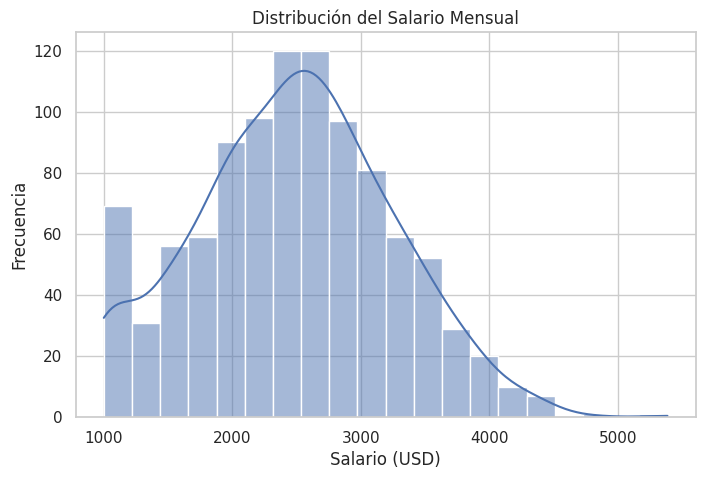

In [7]:
#Grafico

sns.set(style="whitegrid")

# Histograma Salario
plt.figure(figsize=(8,5))
sns.histplot(df_hr['Salario_Mensual'], bins=20, kde=True)
plt.title("Distribución del Salario Mensual")
plt.xlabel("Salario (USD)")
plt.ylabel("Frecuencia")


Lo que tenemos en el histograma es una distribución relativamente similar a la normal con valores fuertes de frecuencia cerca de los 1000 USD. Tenemos el pico de la distribución alrededor de los 2,500 USD. El kde nos permite ver como se ve la curva adaptada a la distribución.

Text(0, 0.5, 'Frecuencia')

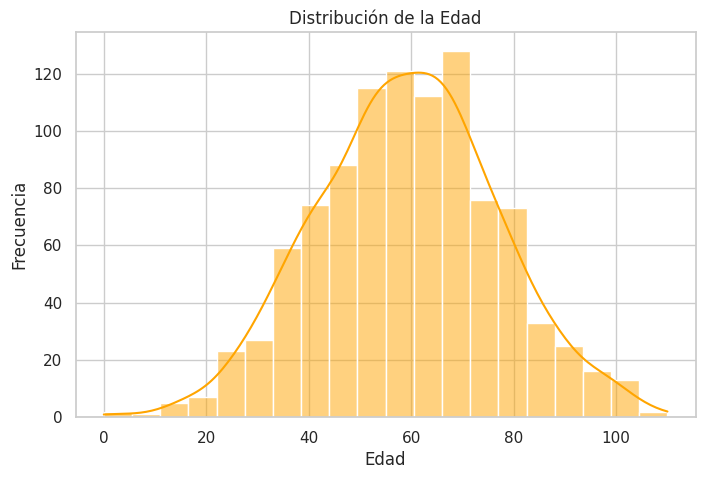

In [9]:
#Histograma 2 Edad
plt.figure(figsize=(8,5))
sns.histplot(df_hr['Edad'], bins=20, kde=True, color='orange')

plt.title("Distribución de la Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

Tenemos una distribución similar a una distribución normal con valores mas frecuentes de edad alrededor de los 60 años. La mayoría de las personas en el dataset están entre 40 y 80 años... Tiene sentido teniendo en cuenta que la generación de los datos es precisamente para mayores de edad y personas que hay estudiado/tienen carreras profesionales, tecnicos, doctorados etc.

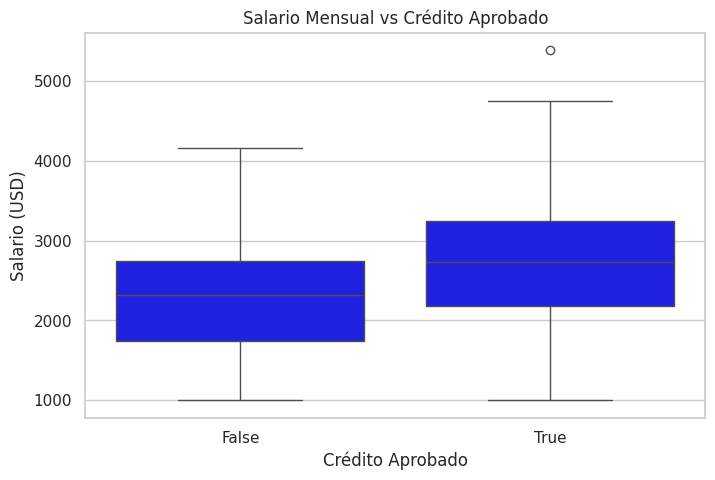

In [13]:
#Boxplot doble con categoría (credito aprobado o no)
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Credito_Aprobado',
    y='Salario_Mensual',
    data=df_hr, color = 'blue'
)
plt.title("Salario Mensual vs Crédito Aprobado")
plt.xlabel("Crédito Aprobado")
plt.ylabel("Salario (USD)")

plt.show()

Podemos ver en los dos boxplots que las medianas del salario para ambos grupos (credito aprobado y no aprobado) estan cerca, entre 2,00 USD y 3,000 USD. Ademas de eso, cuando el credito NO está aprobado, los salarios suelen estar mas bajos con un rango menor (esto fue intencional en como fue construido el dataset sintetico). Cuando vemos los salarios y su boxplot cuando el credito está aprobado podemos notar que los salarios son mas altos, el rango inferior es igual al otro boxplot pero el salario maximo es mayor, ademas de la presencia de un outlier.

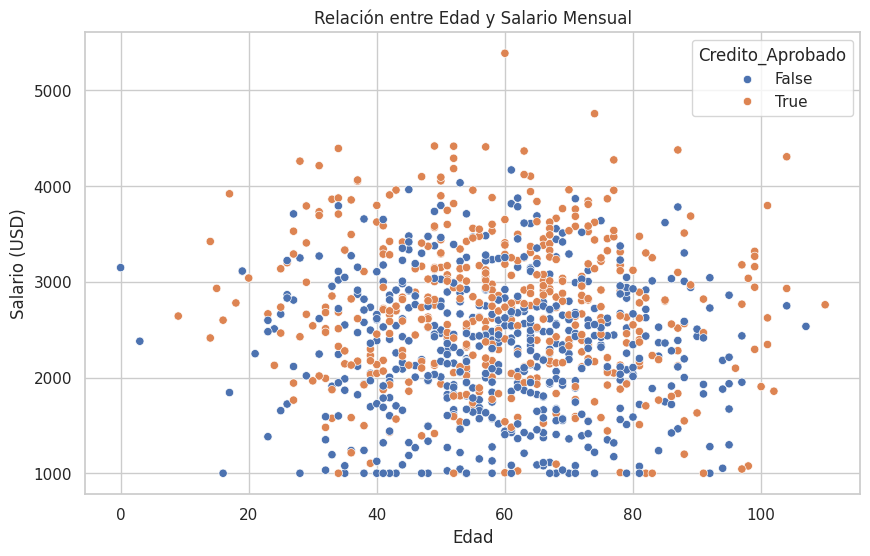

In [18]:
#Scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Edad',
    y='Salario_Mensual',
    hue='Credito_Aprobado',
    data=df_hr
)
plt.title("Relación entre Edad y Salario Mensual")
plt.xlabel("Edad")
plt.ylabel("Salario (USD)")

plt.show()

Nos encontramos con un diagrama que muestra la dispersión entre la edad y los salarios de las personas en el dataset. Tenemos una correlación fuerte y es coherente con lo visto en los demas graficos, el mayor espesor de la nube se concentra entre 40 y 80 años. Los grupos de credito aprobado y no aprobado parecen verse repartidos y la tendencia es que a edades mayores o cuando se tiene un credito aprobado, el salario es mayor.